In [1]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch
import os

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec

In [2]:
# Goal: 
# Define beta value list
# Write anonymous procedure - build_vae(beta, learning_rate)
# Method produces z latent representation, before, 
# after path plots, training, validation, test plots 

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [4]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25

In [5]:
# helper function
def _display_gradients(model: object) -> None:
    print("Showing model gradients")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(name, param.grad.norm().item())
            
def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def _beta_to_str(beta: float) -> str:
    beta_str = f"{beta:.0e}".replace("-", "_").replace("+", "")
    return beta_str

mean_square_error = MeanSquaredError()
mean_square_error = mean_square_error.to(device)

In [6]:
# Loading data
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

# seleting events for the experiment
event_train = events_train[:SELECTED_EVENTS][0]

100%|██████████| 1000/1000 [00:04<00:00, 240.96it/s]


In [7]:
beta_count = 3
(beta_min, beta_max) = (1e-5, 0)
beta_values = list(map(float, np.linspace(beta_min, beta_max, beta_count)))

batch_size = 64
# beta = 0

learning_rate = 1e-3
num_epochs = 80
channels = 1
latent_dim = 128

# logs
LOG_EVERY = 10
plot_val_patches_limit = 12


In [8]:
# Setting seed for reproducing results
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [9]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
            if not (np.all(event_patch_flat == 0))
        ]
        
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training, validation, testing data prepearation
train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 12685
Validation set size: 1585
Test set size: 1587


In [11]:
def _get_elbo_loss(
    recon_x: torch.tensor, 
    x: torch.tensor, 
    mu: torch.tensor, 
    logvar: torch.tensor,
    beta
) -> float:
    recon_loss = F.binary_cross_entropy(
        recon_x, 
        x, 
        reduction="mean"
    )
    
    # KL_divergence
    kl_loss = -0.5 * (
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    
    kl_loss = kl_loss.mean()
    
    return (
        recon_loss + beta * kl_loss,
        recon_loss,
        beta,
        kl_loss
    )

In [12]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, hidden_channels * 2, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),
        )
        # self.flatten = nn.Flatten()
        self.fc_mean = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        self.fc_log_var = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        # self.fc_mean = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )
        torch.nn.init.xavier_uniform_(self.fc_mean.weight)
        
        # self.fc_log_var = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )        
        torch.nn.init.xavier_uniform_(self.fc_log_var.weight)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )
    
    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        
        
    def forward(self, x):
        # apply convolutional layers with relu activation function
        # print("x range:", x.min().item(), x.max().item())
        
        x_encoded = self.encoder(x)
        
        # get the mean and log variance of the latent space distribution
        z_log_mean = self.fc_mean(x_encoded)
        z_log_var = self.fc_log_var(x_encoded)
        
        self.z_log_mean = torch.clamp(z_log_mean, min=-10, max=10)
        # self.z_log_var = torch.clamp(z_log_var, min=-8, max=1)
        self.z_log_var = torch.tanh(z_log_var) * 8
        
        # sample a latent vector using the reparameterization trick
        
        z = self.reparameterize(self.z_log_mean, self.z_log_var)
        
        output = self.decoder(z)
        
        return output, self.z_log_mean, self.z_log_var, z

In [13]:
model = VAE(
    hidden_channels=64, 
    kernel_size = 4,
    slope=0.01
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

In [14]:
# def build_vae(beta: float) -> tuple:
    
    # print(f"Starting VAE model build with beta = {beta}")
    
def train_vae(beta: float) -> dict:
    
    # loss metric curve values
    average_loss_train_bce = []
    average_loss_valid_bce = []
    
    # validation patch images
    patches_before = []
    patches_after = []
    patches_z = [] # latent vector
    
    # errors MSE
    average_loss_train_mse = []
    average_loss_valid_mse = []
    
    # latent variable mu, logvar
    mu_values_z = []
    logvar_values_z = []
    
    plot_idx = 0
    
    model.train()
    
    for epoch in range(num_epochs):
        train_bce_loss = 0
        train_loss_mse = 0
        kl_loss_total = 0
        
        progress_bar = tqdm(
            enumerate(train_loader),
            total=len(train_loader),
            desc=f'Epoch {epoch+1}/{num_epochs}'
        )
        
        for (_, X_adcs) in progress_bar:
            optimizer.zero_grad()                
            X_adcs = X_adcs.float()
            X_adcs = X_adcs.to(device)
            
            (
                recon_patch, 
                mu,
                logvar,
                _
            ) = model(
                X_adcs
            )
            
            (
                loss, 
                recon_loss, 
                beta, 
                kl_loss
            ) = _get_elbo_loss(recon_patch, X_adcs, mu, logvar, beta)
            
            recon_patch = recon_patch.float().to(device)      
            loss.backward()
            
            # For limiting model parameters scale and preventing parameter 
            # value explosion
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
            
            train_bce_loss += recon_loss.item()
            kl_loss_total += kl_loss.item()
            
            train_loss_mse += mean_square_error(
                recon_patch, 
                X_adcs
            ).item()
            
            optimizer.step()        

            # Update tqdm description with current loss
            progress_bar.set_postfix({'Loss': loss.item()})
            
        avg_loss_bce = train_bce_loss / len(train_loader)
        avg_loss_mse = train_loss_mse / len(train_loader)
        # avg_loss_kl = kl_loss_total / len(train_loader)
        
        print(
            f"Epoch [{epoch + 1}/{num_epochs}]"
            f"Average Loss: BCE = {avg_loss_bce:.4f}, "
        )
        
        average_loss_train_bce.append(avg_loss_bce)
        average_loss_train_mse.append(avg_loss_mse)
        
        with torch.no_grad():
            model.eval()
            
            total_bce_loss = 0
            total_mse_loss = 0
            
            for patch_val in val_loader:
                patch_val = patch_val.to(device)
                
                (
                    recon_patch, 
                    mu,
                    logvar, 
                    z 
                ) = model(patch_val)
                
                total_bce_loss += F.binary_cross_entropy(
                    patch_val,
                    recon_patch,
                    reduction="mean"
                ).cpu().detach().numpy().item()

                total_mse_loss += mean_square_error(
                    patch_val,
                    recon_patch  
                ).item()
            
            average_loss_val = total_bce_loss / len(val_loader)
            print(f"Average validation set BCE loss: {average_loss_val}")
            
            average_loss_val_mse = total_mse_loss / len(val_loader)
            average_loss_valid_bce.append(average_loss_val)
            average_loss_valid_mse.append(average_loss_val_mse)
            
            if epoch % LOG_EVERY == 0:
                for patch_val in val_loader:
                    
                    # Saving patch before
                    patch_val = patch_val.to(device)
                    
                    (
                        recon_patch,
                        mu,
                        logvar,
                        z
                    ) = model(patch_val)
                    
                    # Collecting latent mu and logvar
                    mu_flatten = _tensor_to_numpy(mu.flatten())
                    mu_values_z.append(mu_flatten)
                    
                    logvar_flatten = _tensor_to_numpy(logvar.flatten())
                    logvar_values_z.append(logvar_flatten)
                    
                    if plot_idx < plot_val_patches_limit:                        
                        patch_val_ts = _tensor_to_numpy(
                            patch_val.squeeze(1)
                        )
                        patches_before.append(patch_val_ts[0])
                        
                        recon_patch_np = _tensor_to_numpy(
                            recon_patch.squeeze(1)
                        )
                        
                        patches_after.append(recon_patch_np[0])  
                        
                        # Saving latent vector
                        z_np = _tensor_to_numpy(z[0][0])
                        patches_z.append(z_np) 
                        
                        plot_idx += 1
    
    
    beta_str = _beta_to_str(beta)
    model_name = f"vae_beta_{beta_str}.pth"
    print(f"Saving trained VAE model, beta = {beta:.3f}")
    torch.save(model.state_dict(), model_name)
    
    return {
        "vae_model_name" : model_name, # if empty, means skipped since files exist
        "patches" : [
            patches_before, 
            patches_z,
            patches_after
        ],
        "loss" : {
            "train" : average_loss_train_bce,
            "val" : average_loss_valid_bce
        },
        "error" : {
            "train" : average_loss_train_mse,
            "val" : average_loss_valid_mse
        },
        "latent" : {
            "valid" : [
                mu_values_z, 
                logvar_values_z
            ]
        },
        "beta" : beta,
        "beta_str" : beta_str, # for mode name resolving
        "epochs" : num_epochs
    }

def test_vae(beta: float, beta_str: str) -> dict:
    model.load_state_dict(torch.load(f"vae_beta_{beta_str}.pth"))
    model.eval()
    
    patch_display_limit = 12
    patches_after_test = []
    patches_before_test = []
    patches_z = [] # latent vector

    bce_total_value = 0

    test_set_size = len(test_loader)

    for patch_test in test_loader:
        patch_test = patch_test.to(device)                     
        (
            recon_patch, 
            _,
            _,
            z
        ) = model(patch_test)
        
        if len(patches_after_test) < patch_display_limit:
            patch_test_np = patch_test[0][0].cpu().detach().numpy()
            patches_before_test.append(patch_test_np)
            
            recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
            patches_after_test.append(recon_patch_np)
            z_np = _tensor_to_numpy(z[0][0])
            
            patches_z.append(z_np)
        
        # mse_loss = F.mse_loss(patch_test, recon_patch).item()
        bce_loss = F.binary_cross_entropy(
            patch_test, 
            recon_patch, 
            reduction="mean"
        ).cpu().detach().numpy().item()
        
        bce_total_value += bce_loss
        
    bce_loss_average = bce_total_value / test_set_size

    # print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")
    
    return {
        "bce_loss" : bce_loss_average,
        "patches" : [
             patches_before_test, 
             patches_z, 
             patches_after_test
        ]
    }




In [15]:
# TODO
# Plot loss and residual curves
# Plot distributions
# plot patch plots

model_results_curves = []
model_results_latent_mus = []
model_results_latent_logvars = []
model_results_patches = []

for beta in beta_values:  
    
    print(f"Running VAE train with beta = {beta}")
    train_result = train_vae(beta)
    
    print(f"Running VAE test with beta = {beta}\n")
    test_result = test_vae(beta, train_result["beta_str"])
    
    curve = {
        "beta" : beta,
        "train" : {
            "loss" : train_result["loss"],
            "error" : train_result["error"]
        },
        "test" : {
            "bce_loss" : test_result["bce_loss"]
        }
    }
    model_results_curves.append(curve)
    
    latent_mu = {
        "beta" : beta,
        "z_mu" : train_result["latent"]["valid"][0]
    }
    
    model_results_latent_mus.append(latent_mu)
    
    latent_logvar = {
        "beta" : beta,
        "z_logvar" : train_result["latent"]["valid"][1]
    }
    model_results_latent_logvars.append(latent_logvar)
    
    patches = {
        "beta" : beta,
        "valid" : train_result["patches"],
        "test" : test_result["patches"]
    }
    
    model_results_patches.append(patches)
    
print("DONE")

Running VAE train with beta = 1e-05


Epoch 1/80: 100%|██████████| 199/199 [00:00<00:00, 363.70it/s, Loss=0.0355]


Epoch [1/80]Average Loss: BCE = 0.0745, 
Average validation set BCE loss: 0.7911073923110962


Epoch 2/80: 100%|██████████| 199/199 [00:00<00:00, 520.09it/s, Loss=0.0309]


Epoch [2/80]Average Loss: BCE = 0.0366, 
Average validation set BCE loss: 0.40653615951538086


...

Epoch [78/80]Average Loss: BCE = 0.0252, 
Average validation set BCE loss: 0.07873613618314267


Epoch 79/80: 100%|██████████| 199/199 [00:00<00:00, 521.04it/s, Loss=0.0209]


Epoch [79/80]Average Loss: BCE = 0.0252, 
Average validation set BCE loss: 0.07568478390574455


Epoch 80/80: 100%|██████████| 199/199 [00:00<00:00, 519.88it/s, Loss=0.0225]


Epoch [80/80]Average Loss: BCE = 0.0252, 
Average validation set BCE loss: 0.0757496252655983
Saving trained VAE model, beta = 0.000
Running VAE test with beta = 0.0

DONE


In [16]:
beta_values

[1e-05, 5e-06, 0.0]

Plotting all the VAE curves


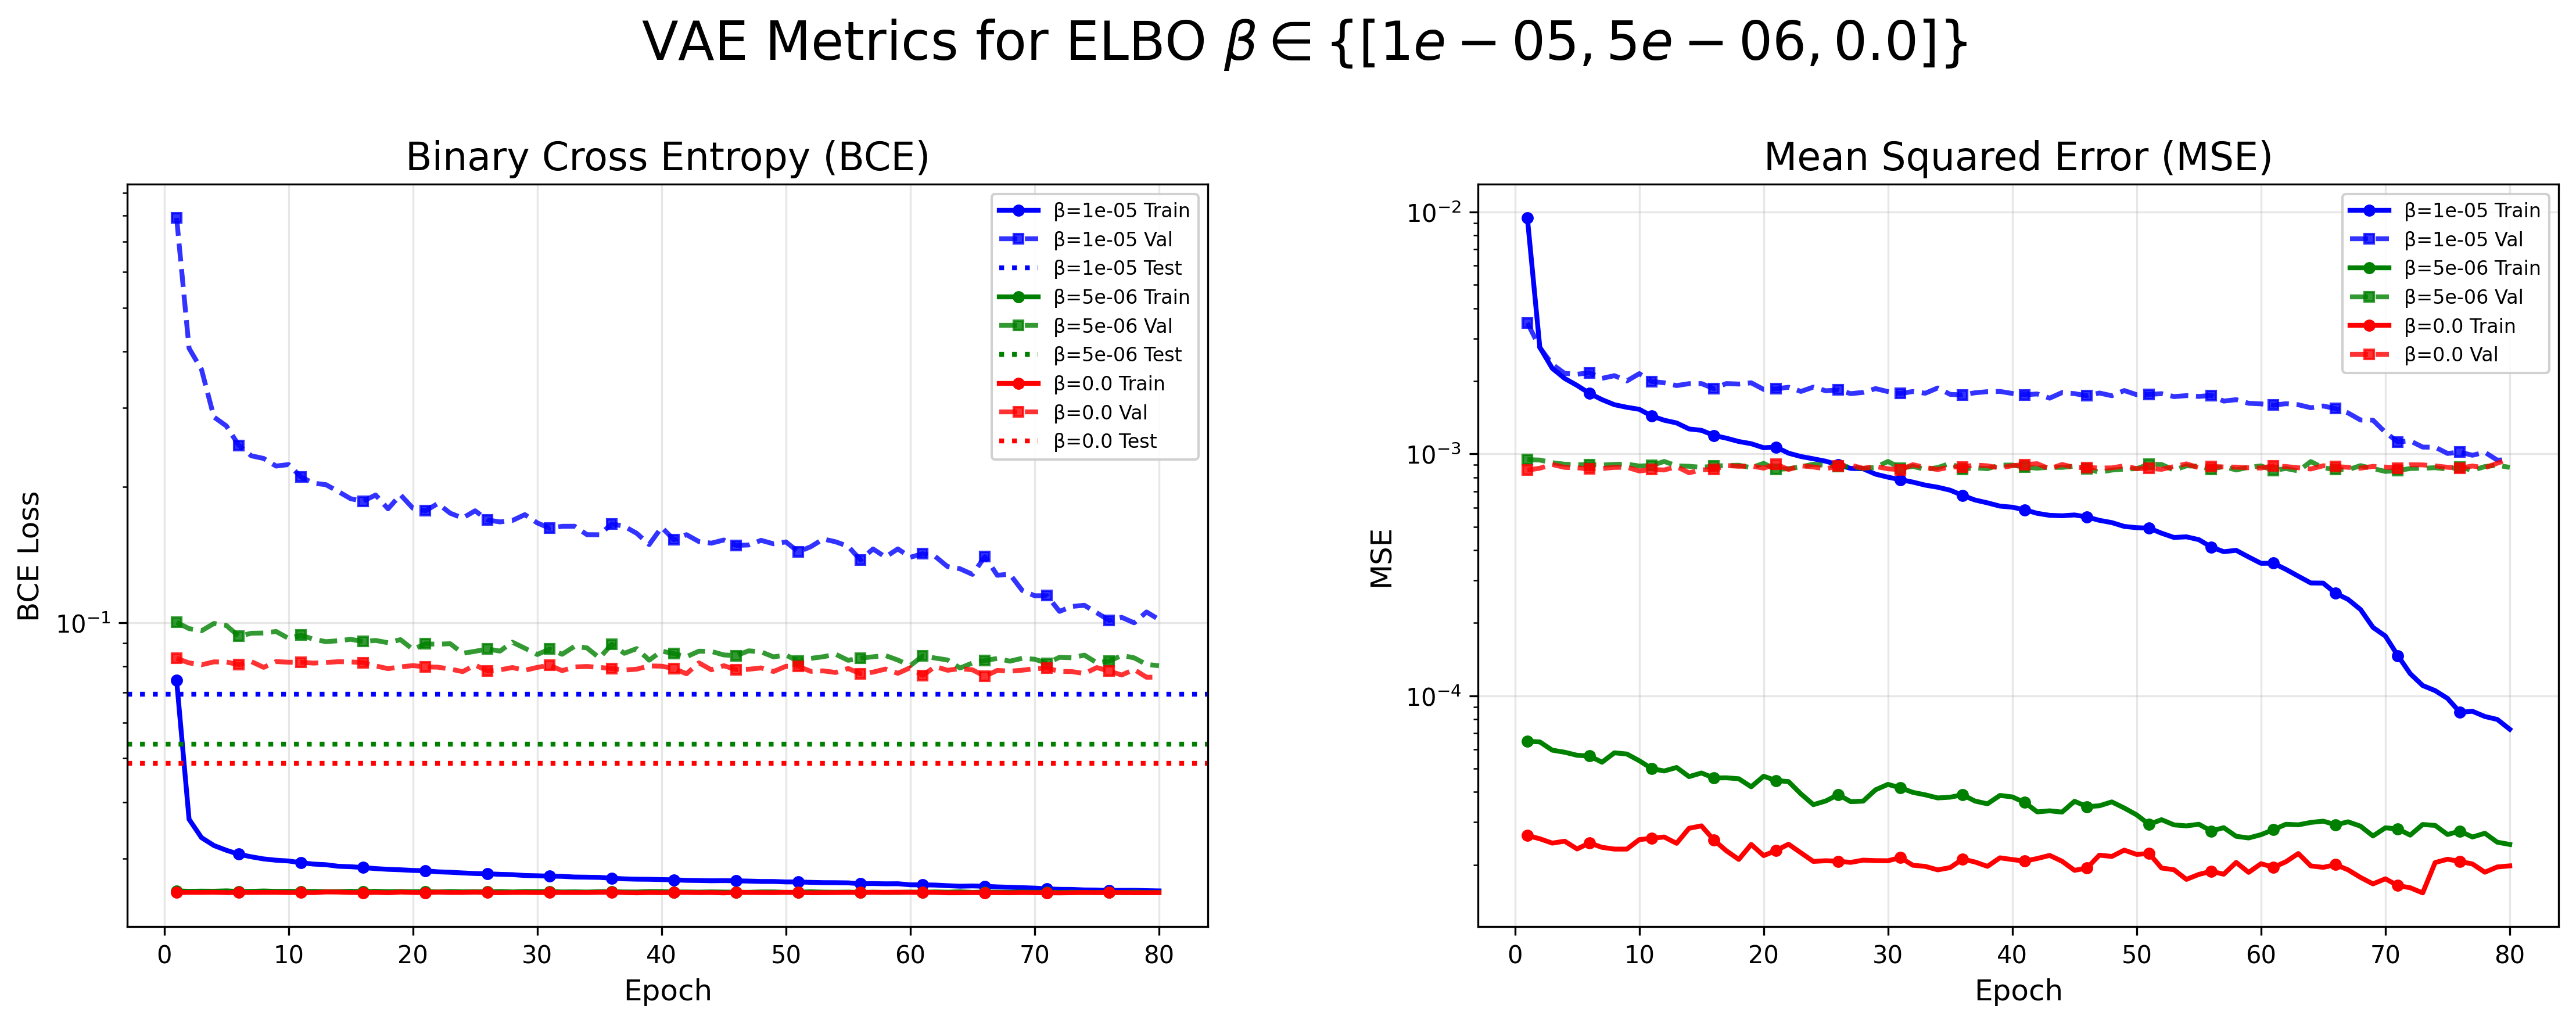

In [17]:
print("Plotting all the VAE curves")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 6),
    dpi=300
)

ax_bce = axes[0]
ax_mse = axes[1]

colors = {
    beta_values[0]: "blue",
    beta_values[1]: "green",
    beta_values[2]: "red",
}

epochs = list(range(1, num_epochs + 1))

# ==========================================
# PLOTTING
# ==========================================
for curve in model_results_curves:

    beta = curve["beta"]
    c = colors[beta]

    # --------------------------------------
    # BCE
    # --------------------------------------

    # Train BCE
    ax_bce.plot(
        epochs,
        curve["train"]["loss"]["train"],
        color=c,
        linestyle="-",
        linewidth=2,
        marker="o",
        markersize=4,
        markevery=5,
        label=f"β={beta} Train"
    )

    # Validation BCE
    ax_bce.plot(
        epochs,
        curve["train"]["loss"]["val"],
        color=c,
        linestyle="--",
        linewidth=2,
        marker="s",
        markersize=4,
        markevery=5,
        alpha=0.8,
        label=f"β={beta} Val"
    )

    # Test BCE
    ax_bce.axhline(
        y=curve["test"]["bce_loss"],
        color=c,
        linestyle=":",
        linewidth=2,
        label=f"β={beta} Test"
    )

    # --------------------------------------
    # MSE
    # --------------------------------------

    # Train MSE
    ax_mse.plot(
        epochs,
        curve["train"]["error"]["train"],
        color=c,
        linestyle="-",
        linewidth=2,
        marker="o",
        markersize=4,
        markevery=5,
        label=f"β={beta} Train"
    )

    # Validation MSE
    ax_mse.plot(
        epochs,
        curve["train"]["error"]["val"],
        color=c,
        linestyle="--",
        linewidth=2,
        marker="s",
        markersize=4,
        markevery=5,
        alpha=0.8,
        label=f"β={beta} Val"
    )

# ==========================================
# BCE SUBPLOT FORMATTING
# ==========================================

ax_bce.set_title(
    "Binary Cross Entropy (BCE)",
    fontsize=16
)

ax_bce.set_xlabel(
    "Epoch",
    fontsize=12
)

ax_bce.set_ylabel(
    "BCE Loss",
    fontsize=12
)
ax_bce.set_yscale("log")

ax_bce.grid(
    True,
    alpha=0.3
)

# ==========================================
# MSE SUBPLOT FORMATTING
# ==========================================

ax_mse.set_title(
    "Mean Squared Error (MSE)",
    fontsize=16
)

ax_mse.set_xlabel(
    "Epoch",
    fontsize=12
)

ax_mse.set_ylabel(
    "MSE",
    fontsize=12
)
ax_mse.set_yscale("log")
# Optional log-scale
# ax_mse.set_yscale("log")

ax_mse.grid(
    True,
    alpha=0.3
)

# ==========================================
# LEGENDS
# ==========================================

ax_bce.legend(
    fontsize=8,
    framealpha=0.9,
    loc="upper right"
)

ax_mse.legend(
    fontsize=8,
    framealpha=0.9,
    loc="upper right"
)

# ==========================================
# MAIN TITLE
# ==========================================

fig.suptitle(
    rf"VAE Metrics for ELBO $\beta \in \{{{beta_values}\}}$",
    fontsize=22
)

# ==========================================
# SPACING
# ==========================================

plt.subplots_adjust(
    wspace=0.25,
    top=0.82
)

plt.show()

Plotting latent distributions per patch from validation set


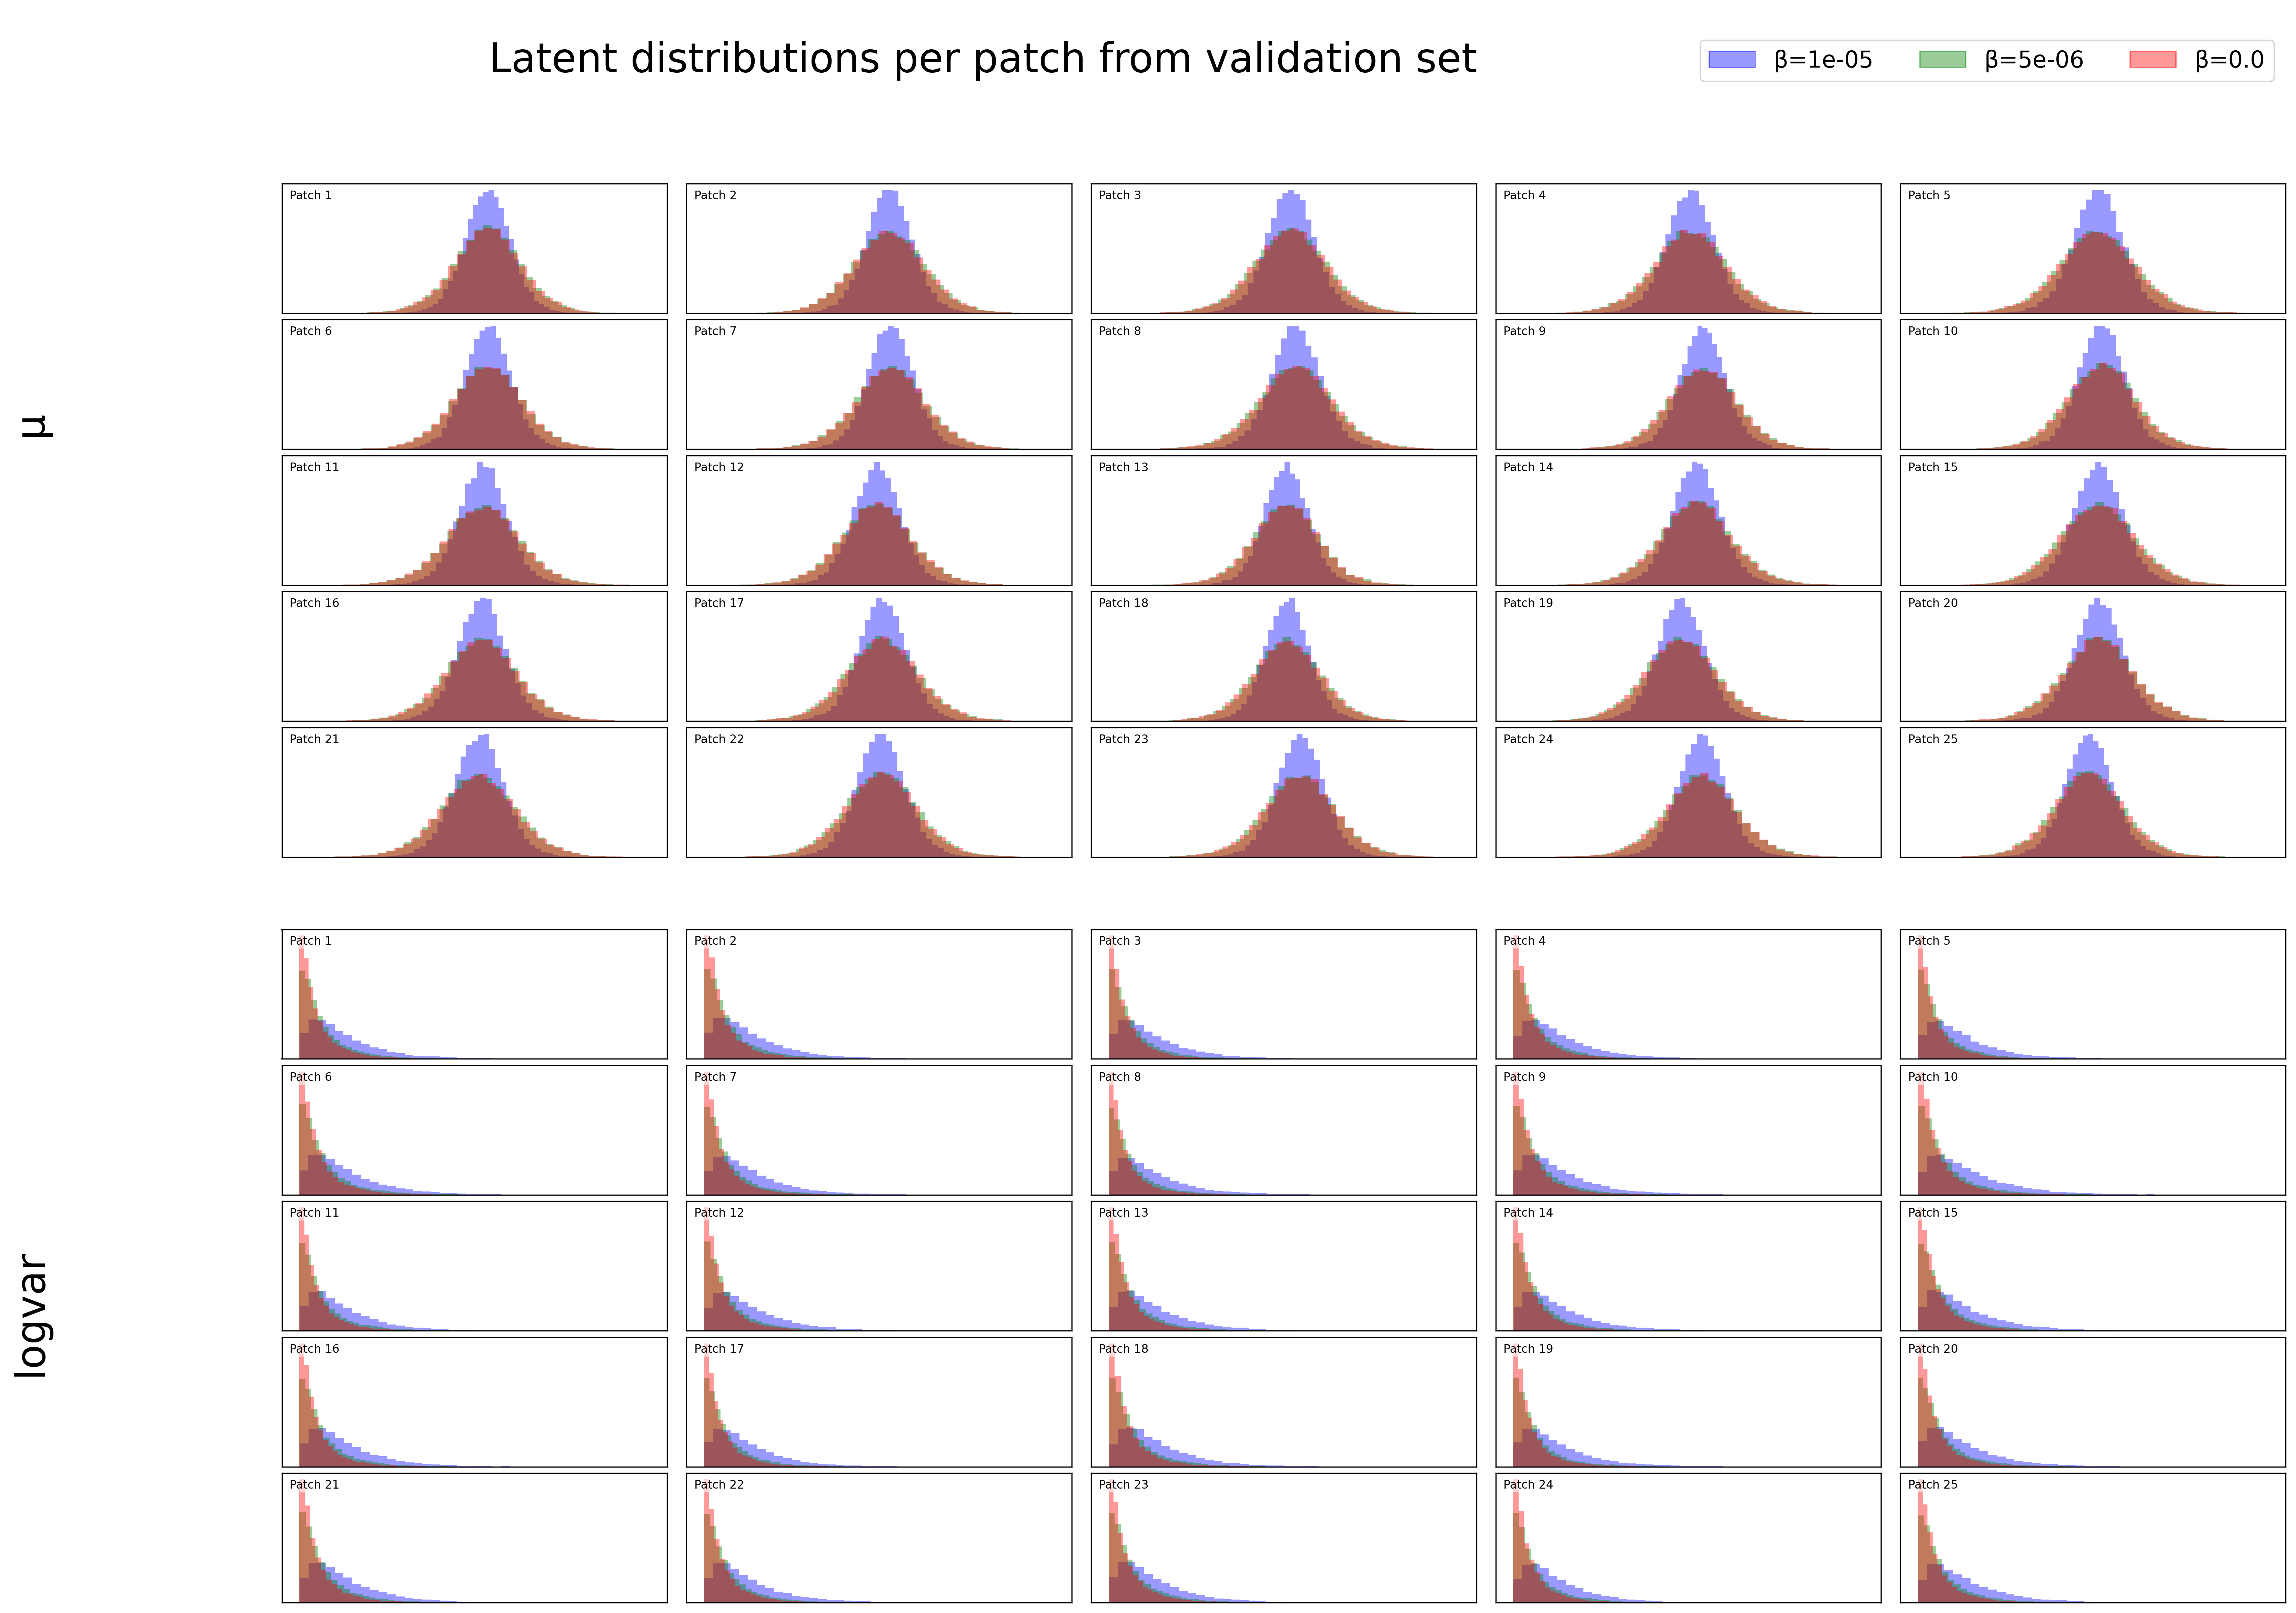

In [18]:
print("Plotting latent distributions per patch from validation set")

colors = ["blue", "green", "red"]

n_patches = 25
n_betas = len(model_results_latent_mus)

fig = plt.figure(figsize=(25, 20), dpi=300)

# ---------------------------------
# Main layout
# ---------------------------------
outer = GridSpec(
    3,
    1,
    height_ratios=[0.15, 1, 1],
    hspace=0.15
)

# ---------------------------------
# Title / legend row
# ---------------------------------
title_ax = fig.add_subplot(outer[0])
title_ax.axis("off")

title_ax.text(
    0.35,
    0.5,
    "Latent distributions per patch from validation set",
    fontsize=28,
    va="center",
    ha="center"
)

# dummy handles for legend
handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors[i], alpha=0.4)
    for i in range(n_betas)
]

labels = [
    f"β={item['beta']}"
    for item in model_results_latent_mus
]

title_ax.legend(
    handles,
    labels,
    loc="center right",
    ncol=n_betas,
    fontsize=16,
    frameon=True
)

# ---------------------------------
# μ GRID
# ---------------------------------
mu_grid = outer[1].subgridspec(
    5,
    5,
    wspace=0.05,
    hspace=0.05
)

mu_axes = []

for patch_idx in range(n_patches):

    r = patch_idx // 5
    c = patch_idx % 5

    ax = fig.add_subplot(mu_grid[r, c])

    mu_axes.append(ax)

    for beta_idx, item in enumerate(model_results_latent_mus):

        mu_values = item["z_mu"][patch_idx].ravel()

        ax.hist(
            mu_values,
            bins=40,
            density=True,
            alpha=0.4,
            color=colors[beta_idx]
        )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.text(
        0.02,                 # x inside axes
        0.95,                 # y inside axes
        f"Patch {patch_idx+1}",
        transform=ax.transAxes,
        fontsize=8,
        va="top",
        ha="left",
        bbox=dict(
            facecolor="white",
            alpha=0.6,
            edgecolor="none",
            pad=1
        )
    )

# section label
fig.text(
    0.02,
    0.68,
    "μ",
    fontsize=28,
    rotation=90,
    va="center"
)

# ---------------------------------
# logvar GRID
# ---------------------------------
logvar_grid = outer[2].subgridspec(
    5,
    5,
    wspace=0.05,
    hspace=0.05
)

for patch_idx in range(n_patches):

    r = patch_idx // 5
    c = patch_idx % 5

    ax = fig.add_subplot(logvar_grid[r, c])

    for beta_idx, item in enumerate(model_results_latent_logvars):

        logvar_values = item["z_logvar"][patch_idx].ravel()

        ax.hist(
            logvar_values,
            bins=40,
            density=True,
            alpha=0.4,
            color=colors[beta_idx]
        )

    ax.set_xticks([])
    ax.set_yticks([])

    ax.text(
        0.02,                 # x inside axes
        0.95,                 # y inside axes
        f"Patch {patch_idx+1}",
        transform=ax.transAxes,
        fontsize=8,
        va="top",
        ha="left",
        bbox=dict(
            facecolor="white",
            alpha=0.6,
            edgecolor="none",
            pad=1
        )
    )

# section label
fig.text(
    0.02,
    0.25,
    "logvar",
    fontsize=28,
    rotation=90,
    va="center"
)

plt.show()

In [19]:
len(model_results_latent_mus[0]["z_mu"])

200

In [25]:
print("Plotting patches")

n_groups = len(model_results_patches)

# ==========================================
# LAYOUT CONFIG
# ==========================================

rows_per_beta = 8

n_rows = n_groups * rows_per_beta

height_ratios = []

for _ in range(n_groups):

    height_ratios.extend([
        0.35,   # VALID title
        1.5,    # VALID before
        0.5,    # VALID latent
        1.5,    # VALID after

        0.35,   # TEST title
        1.5,    # TEST before
        0.5,    # TEST latent
        1.5     # TEST after
    ])

# ==========================================
# FIGURE
# ==========================================

fig = plt.figure(
    figsize=(60, 50),
    dpi=300
)

plt.subplots_adjust(
    left=0.035,
    right=0.98,
    top=0.95,
    bottom=0.03
)

fig.suptitle(
    rf"Event hits patches compression based on VAE and betas "
    rf"$\in \{{{beta_values}\}}$",
    fontsize=60,
    y=0.995
)

# ==========================================
# GRID
# ==========================================

gs = GridSpec(
    n_rows,
    plot_val_patches_limit,
    height_ratios=height_ratios,
    hspace=0.15
)

axes = []

for r in range(n_rows):

    row_axes = []

    for c in range(plot_val_patches_limit):

        ax = fig.add_subplot(gs[r, c])

        row_axes.append(ax)

    axes.append(row_axes)

# ==========================================
# MAIN LOOP
# ==========================================

for beta_idx, item in enumerate(model_results_patches):

    beta = item["beta"]

    row_base = beta_idx * rows_per_beta

    # ======================================
    # VALIDATION SECTION
    # ======================================

    valid_title_row = row_base
    valid_start_row = row_base + 1

    for ax in axes[valid_title_row]:
        ax.axis("off")

    valid_title_y = (
        axes[valid_title_row][0].get_position().y0 +
        axes[valid_title_row][0].get_position().y1
    ) / 2

    fig.text(
        0.5,
        valid_title_y,
        f"Validation set — β={beta}",
        ha="center",
        va="center",
        fontsize=36,
        fontweight="bold"
    )

    (
        before_valid,
        latent_valid,
        after_valid
    ) = item["valid"]

    datasets_valid = [
        before_valid,
        latent_valid,
        after_valid
    ]
    
    print(len(before_valid))

    row_titles = [
        "Before",
        "Latent",
        "After"
    ]

    for row_idx, data in enumerate(datasets_valid):

        row = valid_start_row + row_idx

        for i in range(plot_val_patches_limit):

            ax = axes[row][i]

            ax.imshow(
                data[i],
                cmap="gist_yarg"
            )

            # clean axes
            ax.set_xticks([])
            ax.set_yticks([])

            # borders
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.5)

            # row label
            if i == 0:

                y_center = (
                    axes[row][0].get_position().y0 +
                    axes[row][0].get_position().y1
                ) / 2

                fig.text(
                    0.01,
                    y_center,
                    row_titles[row_idx],
                    fontsize=30,
                    va="center",
                    fontweight="bold"
                )

    # ======================================
    # TEST SECTION
    # ======================================

    test_title_row = row_base + 4
    test_start_row = row_base + 5

    for ax in axes[test_title_row]:
        ax.axis("off")

    test_title_y = (
        axes[test_title_row][0].get_position().y0 +
        axes[test_title_row][0].get_position().y1
    ) / 2

    fig.text(
        0.5,
        test_title_y,
        f"Test set — β={beta}",
        ha="center",
        va="center",
        fontsize=36,
        fontweight="bold"
    )

    (
        before_test,
        latent_test,
        after_test
    ) = item["test"]

    datasets_test = [
        before_test,
        latent_test,
        after_test
    ]

    for row_idx, data in enumerate(datasets_test):

        row = test_start_row + row_idx

        for i in range(plot_val_patches_limit):

            ax = axes[row][i]

            ax.imshow(
                data[i],
                cmap="gist_yarg"
            )

            # clean axes
            ax.set_xticks([])
            ax.set_yticks([])

            # borders
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.5)

            # row label
            if i == 0:

                y_center = (
                    axes[row][0].get_position().y0 +
                    axes[row][0].get_position().y1
                ) / 2

                fig.text(
                    0.01,
                    y_center,
                    row_titles[row_idx],
                    fontsize=30,
                    va="center",
                    fontweight="bold"
                )

# ==========================================
# SHOW
# ==========================================

plt.show()

Plotting patches
12
12
12


In [21]:
len(model_results_patches[0]["valid"][2])

12